# SVM Project

In this notebook we aim to implement Support Vector Machine model for images.   

The dataset we use is [hoda handwritten farsi digit](https://farsiocr.ir/مجموعه-داده/مجموعه-ارقام-دستنویس-هدی).

### Objectives:

* [Preprocessing](#Preprocessing)

* [SVM](#SVM)


In [154]:
import cv2
import optuna
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score

## Preprocessing

In [155]:
# Load data

dataset = loadmat('dataset/Data_hoda_full.mat')


In [156]:
dataset.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [157]:
# Define data and labels

data = dataset['Data']
label = dataset['labels']


In [158]:
labels = set(int(y) for y in label.flatten())
print(f"Labels: {labels}")

Labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [159]:
# Number of samples per each class

pd.Series(label.flatten()).value_counts().sort_index()


0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

In [160]:
print(f"Size of data: {data.shape}\nType: {type(data)}")

Size of data: (60000, 1)
Type: <class 'numpy.ndarray'>


In [161]:
print(f"Size of labels: {label.shape}\nType: {type(label)}")

Size of labels: (60000, 1)
Type: <class 'numpy.ndarray'>


In [ ]:
# Remove axes of length 1 from the array and choose only 2500 samples due to slow training speed

X = np.squeeze(data[:2500])
y = np.squeeze(label[:2500])


In [163]:
print(f"Size of data: {X.shape}")

Size of data: (2500,)


In [164]:
# We have different image sizes

for _ in range(4):
    idx = np.random.randint(len(X))
    print(X[idx].shape)


(21, 20)
(30, 15)
(29, 17)
(35, 30)


In [165]:
# So resize them

X_resize = [cv2.resize(img, (28, 28)) for img in X]


In [166]:
for _ in range(4):
    idx = np.random.randint(len(X_resize))
    print(X_resize[idx].shape)

(28, 28)
(28, 28)
(28, 28)
(28, 28)


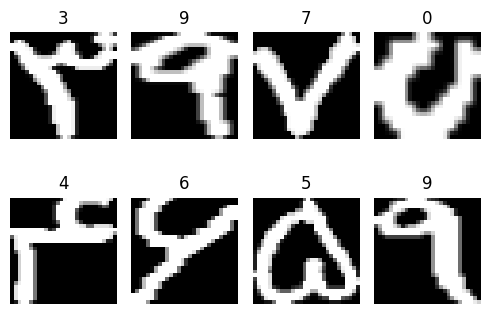

In [204]:
# Display some images

fig, axes = plt.subplots(2, 4, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_resize))
    img = X_resize[idx]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(y[idx])
    plt.tight_layout()

In [168]:
# Create a data frame of data

X_array = np.array(X_resize)  # convert the list to numpy array

X_reshape = np.reshape(X_array, (-1, 28*28*1))  # flatten it to use in data frame

df = pd.DataFrame(X_reshape)

df['label'] = y


In [169]:
df

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,109,255,255,109,0,...,0,0,0,0,0,0,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,0,77,214,255,255,255,255,255,255,255,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,0,0,0,0,0,0,114,255,255,255,...,168,14,0,0,0,0,0,0,0,0
2496,0,0,0,0,0,0,0,0,5,50,...,250,255,255,255,255,255,255,255,255,1
2497,255,255,255,255,255,255,255,255,255,200,...,1,6,12,17,69,136,204,255,255,1
2498,0,0,0,0,0,4,214,255,255,255,...,255,255,214,4,0,0,0,0,0,5


In [170]:
df.shape

(2500, 785)

In [171]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Columns: 785 entries, 0 to label
dtypes: uint8(785)
memory usage: 1.9 MB


In [172]:
type(df)

pandas.DataFrame

In [173]:
df.dtypes

0        uint8
1        uint8
2        uint8
3        uint8
4        uint8
         ...  
780      uint8
781      uint8
782      uint8
783      uint8
label    uint8
Length: 785, dtype: object

In [174]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,11.947200,18.760400,26.231200,30.516800,32.444400,35.645600,41.352800,45.921200,51.561600,55.984400,...,42.515200,40.160000,40.656400,42.468000,46.029600,52.105200,55.806400,49.934800,34.815200,4.492000
std,51.153063,60.057041,70.644255,75.303538,76.785179,80.937534,85.892119,89.805186,93.926515,96.746568,...,87.504143,85.402491,85.446116,86.763537,88.419626,93.076198,97.127998,93.141754,84.422229,2.870197
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,18.250000,36.000000,70.500000,...,5.000000,4.000000,3.250000,9.000000,22.000000,64.000000,73.000000,23.000000,0.000000,7.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,9.000000


In [175]:
df['label'].value_counts().sort_index()

label
0    252
1    237
2    263
3    253
4    248
5    263
6    244
7    245
8    233
9    262
Name: count, dtype: int64

In [176]:
# Remove duplicate images

df_clean = df.drop_duplicates().reset_index(drop=True)


In [177]:
df_X = df_clean.drop('label', axis=1)

In [178]:
df_X

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,109,255,255,109,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,77,214,255,255,255,255,255,255,255,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,36,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,0,0,0,0,0,0,114,255,255,255,...,255,168,14,0,0,0,0,0,0,0
2496,0,0,0,0,0,0,0,0,5,50,...,205,250,255,255,255,255,255,255,255,255
2497,255,255,255,255,255,255,255,255,255,200,...,0,1,6,12,17,69,136,204,255,255
2498,0,0,0,0,0,4,214,255,255,255,...,177,255,255,214,4,0,0,0,0,0


In [179]:
df_y = df_clean['label']

In [180]:
df_y

0       6
1       5
2       0
3       2
4       7
       ..
2495    0
2496    1
2497    1
2498    5
2499    5
Name: label, Length: 2500, dtype: uint8

In [181]:
# Split data to train and test

X_train, X_test, y_train, y_test = train_test_split(
                                                    df_X,
                                                    df_y,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )


In [182]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
2055,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1961,0,0,0,0,0,0,5,44,225,255,...,0,0,0,0,0,0,0,0,0,0
1864,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2326,0,0,0,0,0,0,0,0,68,241,...,0,0,0,0,0,0,0,0,0,0
461,0,0,0,0,0,155,255,136,0,0,...,0,155,255,255,155,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1095,0,0,0,0,0,0,0,0,0,0,...,2,27,126,255,255,255,227,79,19,0
1130,0,0,0,0,0,0,0,0,0,0,...,168,0,0,0,0,0,0,0,0,0
1294,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [183]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

X_train shape: (2000, 784)
X_test shape:  (500, 784)
y_train shape: (2000,)
y_test shape:  (500,)


In [184]:
pd.Series(y_train).value_counts().sort_index()

label
0    199
1    184
2    209
3    204
4    202
5    214
6    186
7    195
8    193
9    214
Name: count, dtype: int64

# SVM

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for classification and regression. Its idea is simple: it finds the best possible boundary (or line/plane) that separates different categories of data.

Think of it like drawing a line on a scatter plot to separate red dots from blue dots, but with one crucial rule: you must draw the line as far away from the dots on both sides as possible which the distance between the separating hyperplane and the closest data points is called 'Margin'.

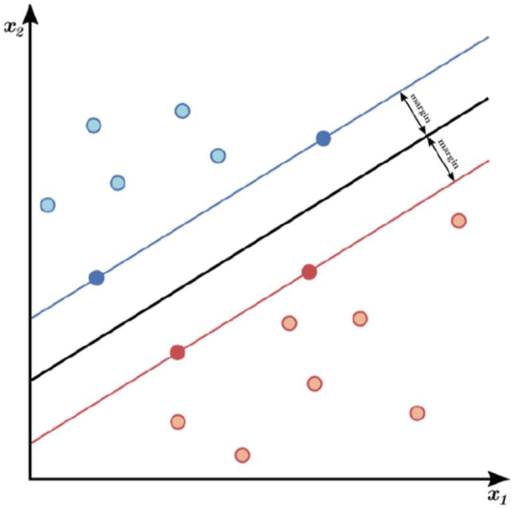

The classic SVM works perfectly when data is linearly separable (you can draw a straight line to separate the classes). But what if the data is not linearly separable?
This is where the Kernel Trick comes in. It's what makes SVMs so powerful.

Instead of trying to find a complex curve in the original, low-dimensional space, the Kernel Trick transforms the data into a higher-dimensional space where a simple straight line (a linear hyperplane) can separate the classes.

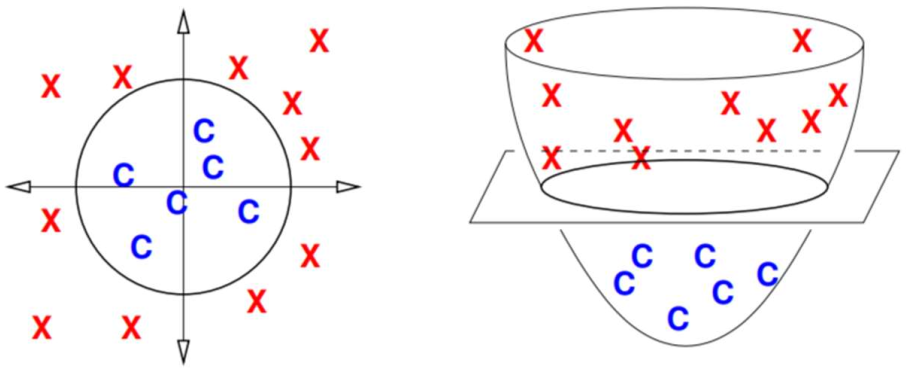

Common Kernels:

* Linear: for linearly separable data. 
    * k ( x_1 , x_2 ) = x_1 . x_2

* Polynomial: for moderately complex relationships.
    * k ( x_1 , x_2 ) = (γ * x_1 . x_2 + C) ^ d

* Radial Basis Function (RBF): great for complex, non-linear data with no clear simple shape.
    * k ( x_1 , x_2 ) = exp⁡(-γ * ‖x_1 - x_2‖ ^ 2)

* Sigmoid: derived from neural networks; can be used as a proxy for a simple two-layer neural network.
    * k ( x_1 , x_2 ) = tanh⁡ (γ * x_1 . x_2 + C)

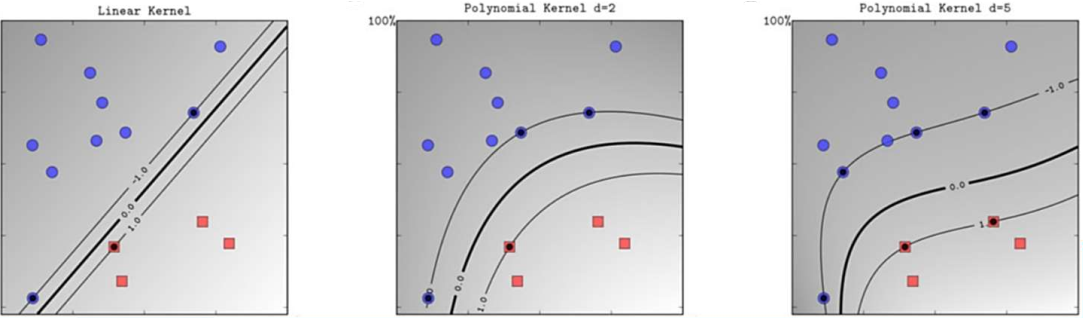

In [ ]:
# Before training SVM model, we find the best hyperparameters using Optuna

def objective_optimized(trial):
    
    # parameters
    C = trial.suggest_float('C', 0.001, 1000, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
    if kernel in ['rbf', 'poly', 'sigmoid']:
        gamma = trial.suggest_float('gamma', 0.0001, 0.1, log=True)
    else:
        gamma = 'scale'
    
    if kernel == 'poly':
        degree = trial.suggest_int('degree', 2, 5)
        coef0 = trial.suggest_float('coef0', 0, 1)
        svm_params = {
            'C': C,
            'kernel': kernel,
            'gamma': gamma,
            'degree': degree,
            'coef0': coef0,
            'random_state': 42}
    else:
        svm_params = {
            'C': C,
            'kernel': kernel,
            'gamma': gamma,
            'random_state': 42}
    
    pipeline = make_pipeline(StandardScaler(), SVC(**svm_params))
    
    # cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    return cv_scores.mean()

# run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective_optimized, n_trials=50, show_progress_bar=True)


[I 2026-04-29 16:34:28,010] A new study created in memory with name: no-name-0598ea5a-ccbe-446c-b388-e9a916eca986


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-29 16:34:57,769] Trial 0 finished with value: 0.908 and parameters: {'C': 1.6841492316036606, 'kernel': 'rbf', 'gamma': 0.0061542161868517594}. Best is trial 0 with value: 0.908.
[I 2026-04-29 16:35:01,506] Trial 1 finished with value: 0.9615 and parameters: {'C': 9.526647606272418, 'kernel': 'linear'}. Best is trial 1 with value: 0.9615.
[I 2026-04-29 16:35:22,838] Trial 2 finished with value: 0.3145 and parameters: {'C': 0.0026978511604032977, 'kernel': 'sigmoid', 'gamma': 0.052077243429748114}. Best is trial 1 with value: 0.9615.
[I 2026-04-29 16:35:36,719] Trial 3 finished with value: 0.966 and parameters: {'C': 223.7885379192222, 'kernel': 'poly', 'gamma': 0.006767753998473766, 'degree': 4, 'coef0': 0.21643177166481864}. Best is trial 3 with value: 0.966.
[I 2026-04-29 16:35:40,238] Trial 4 finished with value: 0.9615 and parameters: {'C': 14.815768106664933, 'kernel': 'linear'}. Best is trial 3 with value: 0.966.
[I 2026-04-29 16:35:44,018] Trial 5 finished with value:

In [206]:
best_params = study.best_params
print(f"Best parameters found: {best_params}\n")
print(f"Best cross-val accuracy: {study.best_value:.4f}")

Best parameters found: {'C': 53.53351355027842, 'kernel': 'poly', 'gamma': 0.0003858137386509275, 'degree': 5, 'coef0': 0.3326161750708533}

Best cross-val accuracy: 0.9780


In [207]:
# Train with best parameters

final_svm = SVC(**best_params, random_state=42)
final_pipeline = make_pipeline(StandardScaler(), final_svm)
final_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",53.53351355027842
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",5
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.0003858137386509275


In [ ]:
# Evaluate on Test data

y_pred = final_pipeline.predict(X_test)


In [209]:
y_pred[:20]

array([3, 9, 6, 6, 7, 8, 9, 9, 6, 1, 3, 0, 2, 6, 3, 4, 9, 2, 1, 6],
      dtype=uint8)

In [210]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        53
           1       0.98      0.96      0.97        53
           2       0.95      0.96      0.95        54
           3       0.98      0.92      0.95        49
           4       0.90      0.98      0.94        46
           5       0.98      1.00      0.99        49
           6       1.00      0.97      0.98        58
           7       1.00      0.98      0.99        50
           8       1.00      1.00      1.00        40
           9       0.98      1.00      0.99        48

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



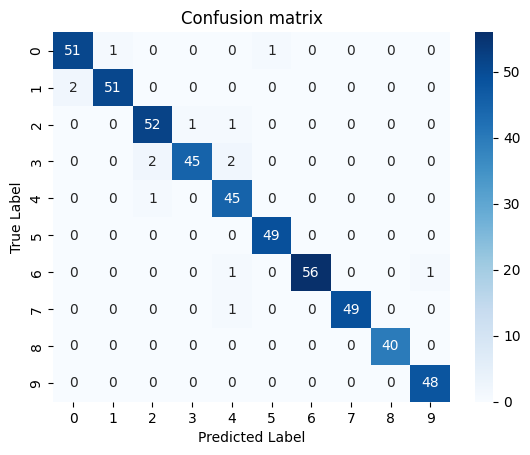

In [211]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


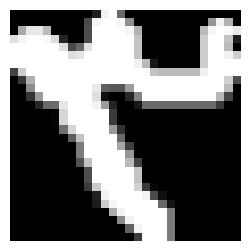

Prediction: 3
True label: 3


In [212]:
# Test a sample

sample = X_test.iloc[[10]]

prediction = final_pipeline.predict(sample)[0]
actual = y_test.iloc[10]

img = sample.values.reshape(28, 28)

plt.figure(figsize=(3, 3))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

print(f"Prediction: {prediction}")
print(f"True label: {actual}")

In [213]:
# Save the model

joblib.dump(final_svm, 'SVM.pkl')


['SVM.pkl']